# 04 — Clusterização espaço-temporal

_Notebook do projeto **crime-sp-ml**. Reaproveita os módulos em `src/`._

In [1]:
import sys, pathlib
from IPython.display import Image, IFrame, display, Markdown
ROOT = pathlib.Path.cwd()
while not (ROOT/'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))
FIG = ROOT/'reports'/'figures'; MAPS = ROOT/'reports'/'maps'; REP = ROOT/'reports'
print('Projeto:', ROOT.name)

Projeto: crime-sp-ml


Aprendizado não supervisionado (`src/clustering.py`): KMeans com elbow + silhouette/Davies-Bouldin/Calinski-Harabasz, e DBSCAN/HDBSCAN em amostra. Recarrega os resultados já calculados (`clustering_metrics.json`).

In [2]:
import json, pandas as pd
metrics = json.load(open(REP/'clustering_metrics.json', encoding='utf-8'))
print('k escolhido:', metrics['k_escolhido'], '| silhouette:', round(metrics['silhouette_k'],3))

k escolhido: 9 | silhouette: 0.317


### Elbow e métricas internas vs k

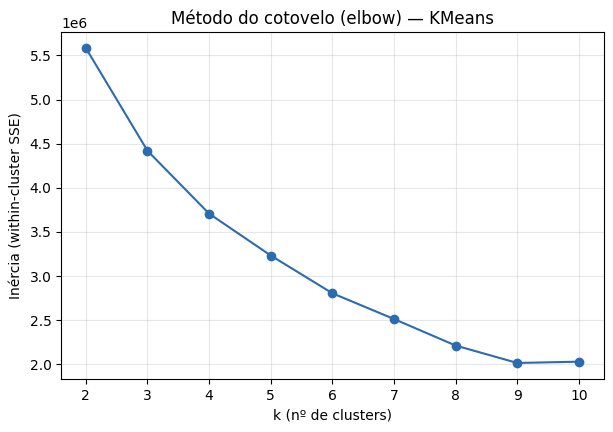

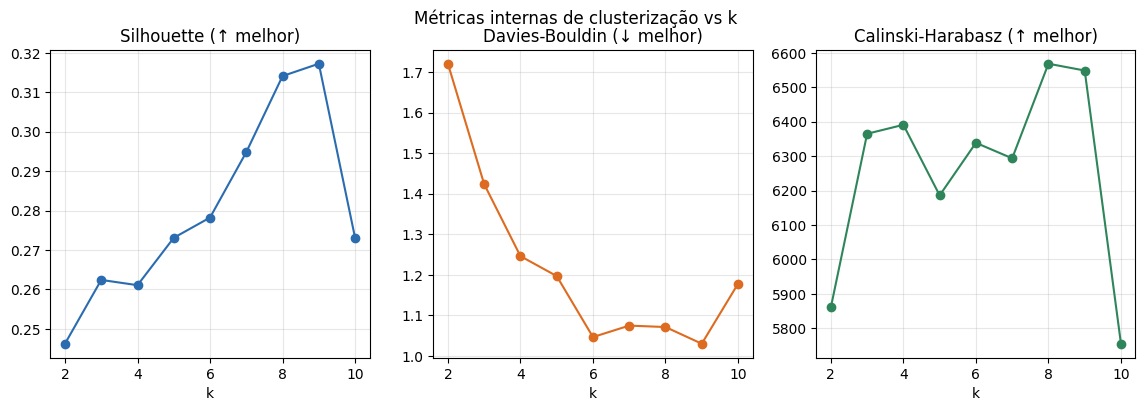

In [3]:
display(Image(filename=str(FIG/'elbow_kmeans.png')))
display(Image(filename=str(FIG/'silhouette_kmeans.png')))

### Resumo por cluster

In [4]:
pd.read_csv(REP/'cluster_summary.csv')

,cluster,n,pct,lat_centro,lon_centro,hora_media,hora_mediana,periodo_dominante,top3_crimes
0,2,326482,18.08,-23.53757,-46.64992,20.5,21.0,Noite (18h–24h),FURTO - OUTROS (168317); ROUBO - OUTROS (10042...
1,5,290480,16.08,-23.53871,-46.62857,15.0,15.0,Tarde (12h–18h),FURTO - OUTROS (178690); ROUBO - OUTROS (50118...
2,3,267628,14.82,-23.54139,-46.64827,9.4,9.0,Manhã (06h–12h),FURTO - OUTROS (163831); ROUBO - OUTROS (47108...
3,8,186050,10.30,-23.53856,-46.64670,3.0,3.0,Madrugada (00h–06h),FURTO - OUTROS (105376); ROUBO - OUTROS (50656...
4,7,176372,9.77,-23.54867,-46.45973,17.7,19.0,Noite (18h–24h),FURTO - OUTROS (63583); ROUBO - OUTROS (57142)...
5,4,158237,8.76,-23.66322,-46.70825,18.6,21.0,Noite (18h–24h),ROUBO - OUTROS (64423); FURTO - OUTROS (55655)...
6,0,147861,8.19,-23.54844,-46.45826,7.4,8.0,Manhã (06h–12h),FURTO - OUTROS (63319); ROUBO - OUTROS (44516)...
7,1,126882,7.03,-23.65953,-46.70437,14.3,15.0,Tarde (12h–18h),FURTO - OUTROS (57085); ROUBO - OUTROS (37723)...
8,6,125969,6.98,-23.67978,-46.71282,6.5,7.0,Manhã (06h–12h),FURTO - OUTROS (59174); ROUBO - OUTROS (41183)...


### DBSCAN / HDBSCAN (amostra) — nº de clusters e ruído

In [5]:
pd.DataFrame(metrics['densidade']['dbscan'])

,eps,min_samples,n_clusters,ruido_pct
0,0.2,10,112,2.9
1,0.2,25,114,24.5
2,0.3,10,34,0.8
3,0.3,25,67,3.8
4,0.5,10,1,0.1
5,0.5,25,1,0.2


In [6]:
pd.DataFrame(metrics['densidade']['hdbscan'])

,min_cluster_size,n_clusters,ruido_pct
0,100,34,56.6
1,250,14,72.7
2,500,4,80.6


### Mapa de clusters (interativo)

In [7]:
display(IFrame(src=str((MAPS/'mapa_clusters.html').relative_to(ROOT)), width='100%', height=480))

**Leitura honesta:** silhouette ≈ 0,3 indica clusters sobrepostos — localização sozinha separa pouco. Ainda assim, a região central se divide em clusters que diferem essencialmente pelo **horário**.